In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from rtnls_inference import SegmentationEnsemble
from tqdm.notebook import tqdm

## Disc segmentation with ONNX

Runs the `disc_may26` ONNX release on preprocessed RGB images in `samples/fundus/rgb`.
Only the test transform (resize to model input) is undone after inference, not fundus preprocessing.

In [2]:
ds_path = Path("../samples/fundus")
disc_onnx_path = Path(
    "/mnt/oogergo/eyened/models/rtnls_vascx/releases_new/disc_may26.onnx"
)
discs_path = ds_path / "discs_onnx"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
rgb_paths = sorted((ds_path / "rgb").glob("*"))
rgb_paths

[PosixPath('../samples/fundus/rgb/CHASEDB1_08L.png'),
 PosixPath('../samples/fundus/rgb/CHASEDB1_12R.png'),
 PosixPath('../samples/fundus/rgb/DRIVE_22.png'),
 PosixPath('../samples/fundus/rgb/DRIVE_40.png'),
 PosixPath('../samples/fundus/rgb/HRF_04_g.png'),
 PosixPath('../samples/fundus/rgb/HRF_07_dr.png')]

In [4]:
data = [{"id": p.stem, "image": str(p)} for p in rgb_paths]

In [5]:
ensemble_disc = SegmentationEnsemble.from_onnx(disc_onnx_path).to(device).eval()
# ensemble_disc.config["datamodule"]["test_transform"]["square_size"] = 1024
# ensemble_disc.save_stored_config()

In [6]:
dataloader = ensemble_disc._make_inference_dataloader(
    {"images": data},
    num_workers=4,
    preprocess=False,
    batch_size=4,
)

In [7]:
discs_path.mkdir(parents=True, exist_ok=True)

results = []
with torch.no_grad():
    for batch in tqdm(dataloader, desc="disc ONNX"):
        if len(batch) == 0:
            continue

        items = ensemble_disc._predict_logits_batch(batch)
        items = [
            dataloader.dataset.transform.undo_item(item, preprocess=False)
            for item in items
        ]

        for item in items:
            logits = item["image"]
            if isinstance(logits, torch.Tensor):
                logits = logits.detach().cpu().numpy()
            mask = np.argmax(logits, axis=-1).astype(np.uint8)
            results.append({"id": item["id"], "mask": mask})
            Image.fromarray(mask).save(discs_path / f"{item['id']}.png")

disc ONNX:   0%|          | 0/2 [00:00<?, ?it/s]

/home/jose/.pyenv/versions/rtnls/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/jose/.pyenv/versions/rtnls/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autog

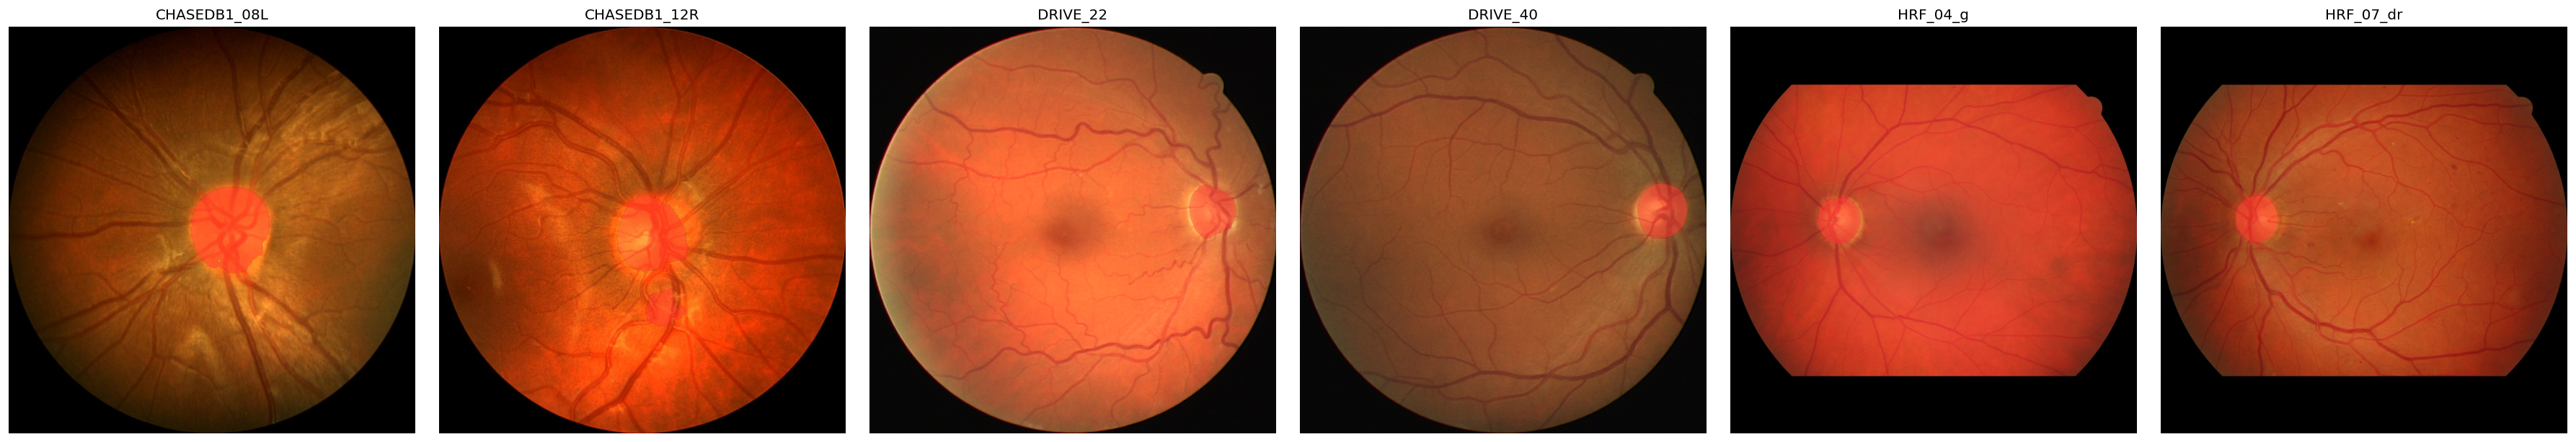

In [8]:
def plot_disc_result(image_path: Path, mask: np.ndarray, ax=None):
    """Show fundus image with disc segmentation overlay."""
    ax = ax or plt.gca()
    image = np.array(Image.open(image_path).convert("RGB"))
    ax.imshow(image)
    overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
    overlay[mask > 0] = [1.0, 0.2, 0.2, 0.45]
    ax.imshow(overlay)
    ax.set_title(image_path.stem)
    ax.axis("off")


n = len(results)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), dpi=120)
if n == 1:
    axes = [axes]

path_by_id = {p.stem: p for p in rgb_paths}
for ax, item in zip(axes, results):
    plot_disc_result(path_by_id[item["id"]], item["mask"], ax=ax)

fig.tight_layout()
plt.show()